In [241]:
plt.tight_layout()
plt.savefig("../reports/charts/aum_trend_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [242]:
# Daily NAV Trend

fig_daily = px.line(
    nav_df,
    x="date",
    y="nav",
    title="Daily NAV Trend"
)

fig_daily.update_layout(
    template="plotly_white",
    title_x=0.5,
    width=1200,
    height=600,
    xaxis_title="Date",
    yaxis_title="NAV"
)

fig_daily.show()

In [243]:
# Save the current figure (run immediately after creating each chart)

plt.savefig("../reports/charts/monthly_transaction_count.png", dpi=300, bbox_inches="tight")

plt.savefig("../reports/charts/total_investment_by_fund.png", dpi=300, bbox_inches="tight")

plt.savefig("../reports/charts/aum_trend_over_time.png", dpi=300, bbox_inches="tight")

print("Charts saved successfully!")

Charts saved successfully!


<Figure size 640x480 with 0 Axes>

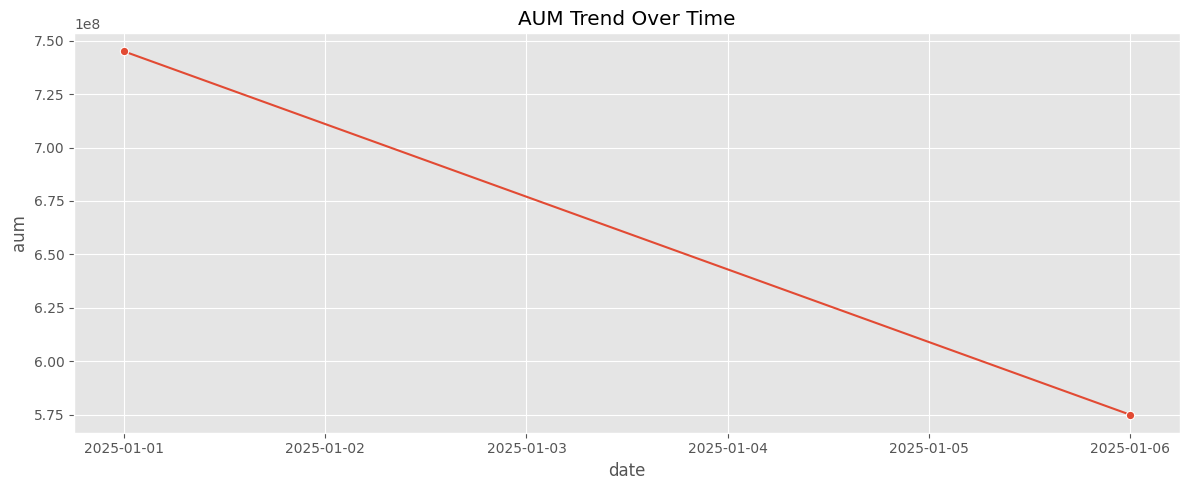

In [244]:
aum_df["date"] = pd.to_datetime(aum_df["date"])

daily_aum = (
    aum_df
    .groupby("date")["aum"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,5))

sns.lineplot(
    data=daily_aum,
    x="date",
    y="aum",
    marker="o"
)

plt.title("AUM Trend Over Time")

plt.tight_layout()

plt.savefig("../reports/charts/aum_trend_over_time.png", dpi=300, bbox_inches="tight")

plt.show()

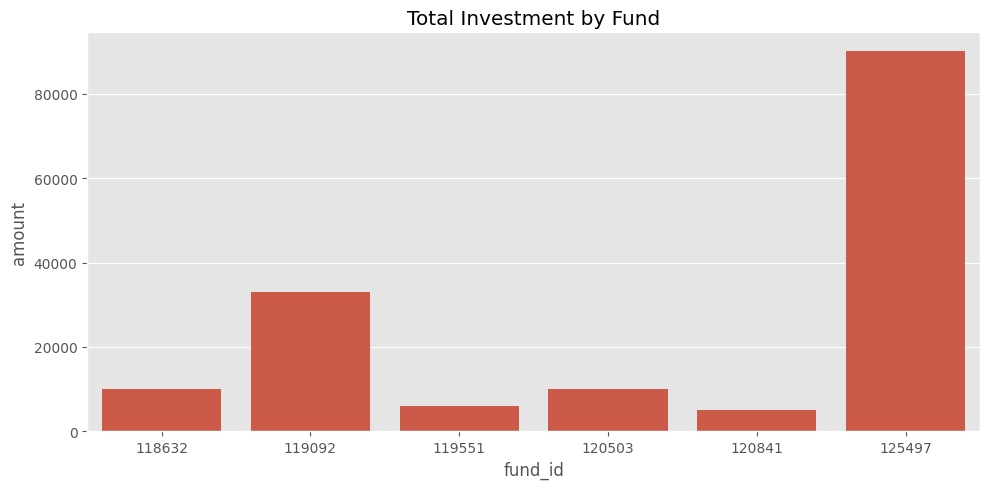

In [245]:
fund_amount = (
    transactions_df
    .groupby("fund_id")["amount"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=fund_amount,
    x="fund_id",
    y="amount"
)

plt.title("Total Investment by Fund")

plt.tight_layout()

plt.savefig("../reports/charts/total_investment_by_fund.png", dpi=300, bbox_inches="tight")

plt.show()

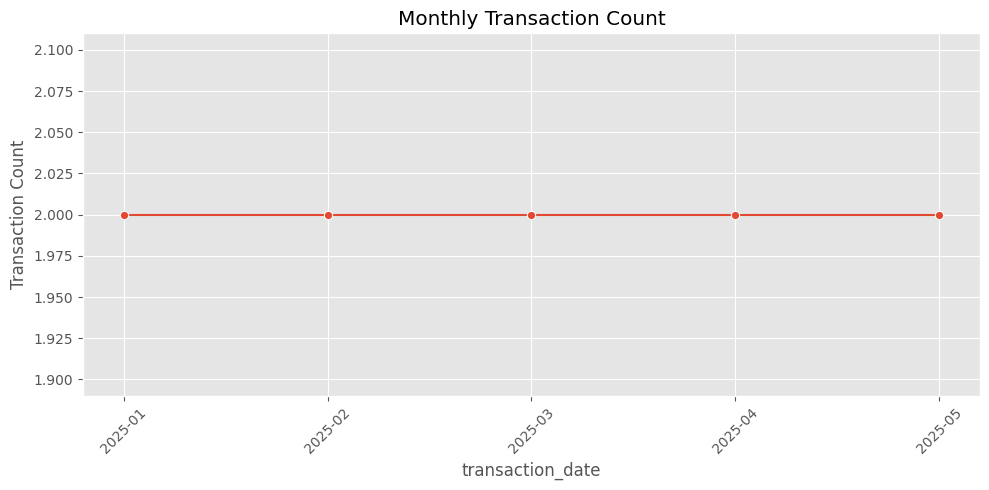

In [246]:
transactions_df["transaction_date"] = pd.to_datetime(transactions_df["transaction_date"])

monthly_transactions = (
    transactions_df
    .groupby(transactions_df["transaction_date"].dt.to_period("M"))
    .size()
    .reset_index(name="Transaction Count")
)

monthly_transactions["transaction_date"] = monthly_transactions["transaction_date"].astype(str)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=monthly_transactions,
    x="transaction_date",
    y="Transaction Count",
    marker="o"
)

plt.title("Monthly Transaction Count")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../reports/charts/monthly_transaction_count.png", dpi=300, bbox_inches="tight")

plt.show()


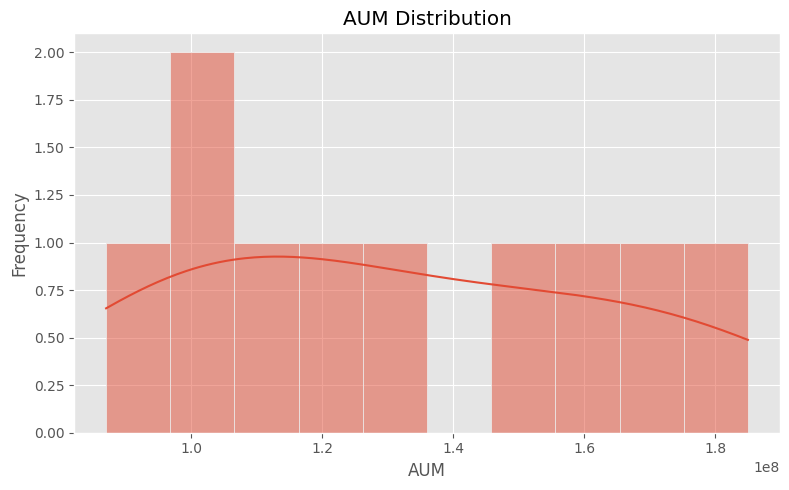

In [248]:
plt.figure(figsize=(8,5))

sns.histplot(
    aum_df["aum"],
    bins=10,
    kde=True
)

plt.title("AUM Distribution")
plt.xlabel("AUM")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../reports/charts/aum_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

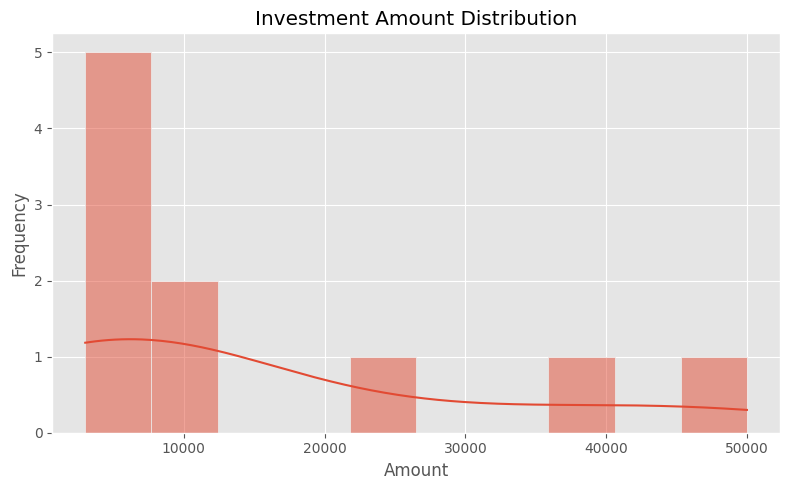

In [249]:
plt.figure(figsize=(8,5))

sns.histplot(
    transactions_df["amount"],
    bins=10,
    kde=True
)

plt.title("Investment Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../reports/charts/investment_amount_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

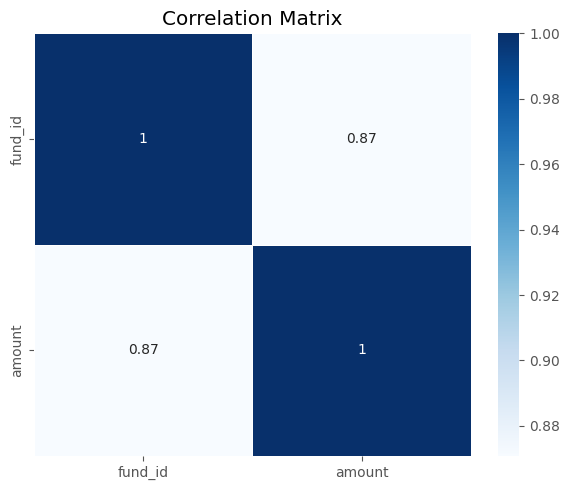

In [250]:
# Correlation Matrix

corr = transactions_df[["fund_id", "amount"]].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig(
    "../reports/charts/correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [251]:
fig.write_html("../reports/charts/monthly_nav_trend.html")

In [252]:
fig.write_html("../reports/charts/daily_nav_trend.html")

In [253]:
monthly_nav = (
    nav_df
    .set_index("date")
    .resample("M")
    .mean()
    .reset_index()
)

fig = px.line(
    monthly_nav,
    x="date",
    y="nav",
    title="Monthly Average NAV",
    markers=True
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5
)

fig.show()

TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'Index'

In [ ]:
print("Average NAV")

print(round(nav_df["nav"].mean(),2))

Average NAV
90.49


In [ ]:
print("Highest NAV")

display(nav_df.loc[nav_df["nav"].idxmax()])

print("\nLowest NAV")

display(nav_df.loc[nav_df["nav"].idxmin()])

Highest NAV


date    2024-10-15 00:00:00
nav                214.6767
Name: 421, dtype: object


Lowest NAV


date    2013-11-22 00:00:00
nav                 12.7775
Name: 3102, dtype: object

In [ ]:
import plotly.express as px

fig = px.line(
    nav_df,
    x="date",
    y="nav",
    title="Daily NAV Trend",
    labels={
        "date": "Date",
        "nav": "NAV"
    }
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    width=1000,
    height=500
)

fig.show()

In [ ]:
# Sort NAV Data by Date

nav_df = nav_df.sort_values("date")

nav_df.head()

,date,nav
3106,2013-11-18,13.0894
3105,2013-11-19,13.1068
3104,2013-11-20,12.9549
3103,2013-11-21,12.7957
3102,2013-11-22,12.7775


In [ ]:
nav_df.dtypes

date    datetime64[ns]
nav            float64
dtype: object

In [ ]:
# Convert Date Columns

nav_df["date"] = pd.to_datetime(nav_df["date"])

transactions_df["transaction_date"] = pd.to_datetime(
    transactions_df["transaction_date"]
)

aum_df["date"] = pd.to_datetime(aum_df["date"])

In [ ]:
# Check Data Types

print("NAV Data")
display(nav_df.dtypes)

print("\nTransactions")
display(transactions_df.dtypes)

print("\nPerformance")
display(performance_df.dtypes)

print("\nAUM")
display(aum_df.dtypes)

NAV Data


date    datetime64[ns]
nav            float64
dtype: object


Transactions


transaction_id               int64
fund_id                      int64
transaction_date    datetime64[ns]
transaction_type            object
amount                       int64
kyc_status                  object
state                       object
Unnamed: 7                  object
dtype: object


Performance


fund_id            int64
return_1y        float64
return_3y        float64
return_5y        float64
expense_ratio    float64
dtype: object


AUM


aum_id                 int64
fund_id                int64
date          datetime64[ns]
aum                    int64
Fund House            object
Year                   int32
dtype: object

In [ ]:
# Statistical Summary

display(nav_df.describe())

display(transactions_df.describe())

display(performance_df.describe())

display(aum_df.describe())

,date,nav
count,3107,3107.000000
mean,2020-03-12 05:38:47.775989504,90.490741
min,2013-11-18 00:00:00,12.777500
25%,2017-01-17 12:00:00,40.305800
50%,2020-03-17 00:00:00,61.559000
75%,2023-05-09 12:00:00,130.899300
max,2026-06-23 00:00:00,214.676700
std,NaN,60.670190


,transaction_id,fund_id,transaction_date,amount
count,10.00000,10.000000,10,10.00000
mean,5.50000,120688.800000,2025-03-11 09:36:00,15400.00000
min,1.00000,118632.000000,2025-01-15 00:00:00,3000.00000
25%,3.25000,119092.000000,2025-02-06 06:00:00,5000.00000
50%,5.50000,119551.000000,2025-03-08 00:00:00,6500.00000
75%,7.75000,120756.500000,2025-04-10 06:00:00,21250.00000
max,10.00000,125497.000000,2025-05-20 00:00:00,50000.00000
std,3.02765,2634.068075,NaN,17030.69125


,fund_id,return_1y,return_3y,return_5y,expense_ratio
count,6.00000,6.000000,6.000000,6.000000,6.000000
mean,120686.00000,13.333333,14.700000,16.466667,0.925000
std,2500.04848,3.392148,3.252691,3.301919,0.223047
min,118632.00000,8.900000,10.500000,12.000000,0.650000
25%,119206.75000,11.225000,12.625000,14.450000,0.775000
50%,120027.00000,13.300000,14.750000,16.500000,0.900000
75%,120756.50000,14.925000,16.125000,18.175000,1.062500
max,125497.00000,18.500000,19.700000,21.300000,1.250000


,aum_id,fund_id,date,aum,Year
count,10.00000,10.000000,10,1.000000e+01,10.0
mean,5.50000,120688.800000,2025-01-03 00:00:00,1.320000e+08,2025.0
min,1.00000,118632.000000,2025-01-01 00:00:00,8.700000e+07,2025.0
25%,3.25000,119092.000000,2025-01-01 00:00:00,1.040000e+08,2025.0
50%,5.50000,119551.000000,2025-01-01 00:00:00,1.275000e+08,2025.0
75%,7.75000,120756.500000,2025-01-06 00:00:00,1.560000e+08,2025.0
max,10.00000,125497.000000,2025-01-06 00:00:00,1.850000e+08,2025.0
std,3.02765,2634.068075,NaN,3.379020e+07,0.0


In [ ]:
# Missing Values

print("NAV")
display(nav_df.isnull().sum())

print("\nTransactions")
display(transactions_df.isnull().sum())

print("\nPerformance")

display(performance_df.isnull().sum())

print("\nAUM")
display(aum_df.isnull().sum())

NAV


date    0
nav     0
dtype: int64


Transactions


transaction_id       0
fund_id              0
transaction_date     0
transaction_type     0
amount               0
kyc_status           0
state                0
Unnamed: 7          10
dtype: int64


Performance


fund_id          0
return_1y        0
return_3y        0
return_5y        0
expense_ratio    0
dtype: int64


AUM


aum_id        0
fund_id       0
date          0
aum           0
Fund House    0
Year          0
dtype: int64

In [ ]:
print("NAV DATA")
nav_df.info()

print("\nTRANSACTION DATA")
transactions_df.info()


print("\nPERFORMANCE DATA")
performance_df.info()

print("\nAUM DATA")
aum_df.info()

NAV DATA
<class 'pandas.core.frame.DataFrame'>
Index: 3107 entries, 3106 to 0
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    3107 non-null   datetime64[ns]
 1   nav     3107 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 137.4 KB

TRANSACTION DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    10 non-null     int64         
 1   fund_id           10 non-null     int64         
 2   transaction_date  10 non-null     datetime64[ns]
 3   transaction_type  10 non-null     object        
 4   amount            10 non-null     int64         
 5   kyc_status        10 non-null     object        
 6   state             10 non-null     object        
 7   Unnamed: 7        0 non-null      object   

In [ ]:
# Dataset Shapes

print("NAV:", nav_df.shape)
print("Transactions:", transactions_df.shape)

print("Performance:", performance_df.shape)
print("AUM:", aum_df.shape)

NAV: (3107, 2)
Transactions: (10, 8)
Performance: (6, 5)
AUM: (10, 6)


In [ ]:
# Load AUM Data

aum_df = pd.read_sql("SELECT * FROM aum", conn)

aum_df.head()

,aum_id,fund_id,date,aum
0,1,118632,01-01-2025,125000000
1,2,119092,01-01-2025,98000000
2,3,119551,01-01-2025,150000000
3,4,120503,01-01-2025,87000000
4,5,120841,01-01-2025,110000000


In [ ]:
# Load Scheme Performance

performance_df = pd.read_sql("SELECT * FROM scheme_performance", conn)

performance_df.head()

,fund_id,return_1y,return_3y,return_5y,expense_ratio
0,118632,12.5,14.2,15.8,0.85
1,119092,10.8,12.1,14.0,1.10
2,119551,15.2,16.4,18.5,0.75
3,120503,8.9,10.5,12.0,1.25
4,120841,14.1,15.3,17.2,0.95


In [ ]:
# Load Investor Transactions

transactions_df = pd.read_sql("SELECT * FROM investor_transactions", conn)

transactions_df.head()

,transaction_id,fund_id,transaction_date,transaction_type,amount,kyc_status,state,Unnamed: 7
0,1,118632,15-01-2025,SIP,5000,Verified,Telangana,None
1,2,119092,20-01-2025,Lumpsum,25000,Verified,AndhraPradesh,None
2,3,119551,05-02-2025,SIP,3000,Pending,Karnataka,None
3,4,120503,10-02-2025,Redemption,10000,Verified,TamilNadu,None
4,5,120841,01-03-2025,SIP,5000,Verified,Maharashtra,None


In [ ]:
# Load NAV Data

nav_df = pd.read_sql("SELECT * FROM nav_processed", conn)

nav_df.head()

,date,nav
0,2026-06-23,203.5443
1,2026-06-22,204.1263
2,2026-06-19,202.0761
3,2026-06-18,200.9565
4,2026-06-17,199.8302


In [ ]:
# Show Available Tables

query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

tables = pd.read_sql(query, conn)

tables

,name
0,nav_processed
1,investor_transactions
2,scheme_performance
3,aum


In [ ]:
# Database Connection

import sqlite3

conn = sqlite3.connect("../bluestock_mf.db")

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import sqlite3
import warnings

warnings.filterwarnings("ignore")

plt.style.use("ggplot")

print("EDA Notebook Started Successfully!")

EDA Notebook Started Successfully!


# Mutual Fund Analytics - Exploratory Data Analysis (EDA)

## Objective

This notebook performs Exploratory Data Analysis (EDA) on Mutual Fund datasets.

### Analysis Covered

- NAV Trend Analysis
- AUM Growth Analysis
- SIP Inflow Analysis
- Category-wise Analysis
- Investor Demographics
- Geographic Distribution
- Correlation Analysis
- Sector Allocation
- Business Insights